In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.cluster import KMeans
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# Load dataset
df = pd.read_csv('/content/engineered_churn_data.csv')

# Load scaler
scaler = joblib.load('/content/scaler.pkl')

print("✅ Data Loaded!")
print("Shape:", df.shape)
df.head()

✅ Data Loaded!
Shape: (7043, 27)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,MonthlyCharges,TotalCharges,Churn,CLV,AvgMonthlySpend,ServiceCount,ContractRiskScore,ElectronicCheckFlag,TenureGroup,HighSpendFlag
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,...,29.85,29.85,0,29.85,29.850000,1,3,1,New,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,...,56.95,1889.50,0,1936.30,55.573529,3,2,0,Mature,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,...,53.85,108.15,1,107.70,54.075000,3,3,0,New,0
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,...,42.30,1840.75,0,1903.50,40.905556,3,2,0,Mature,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,...,70.70,151.65,1,141.40,75.825000,1,3,1,New,1


In [2]:
# Encode categorical columns
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
le = LabelEncoder()

for col in cat_cols:
    df[col] = le.fit_transform(df[col].astype(str))

# Select features for clustering
cluster_features = [
    'tenure',
    'MonthlyCharges',
    'TotalCharges',
    'CLV',
    'AvgMonthlySpend',
    'ServiceCount',
    'ContractRiskScore',
    'ElectronicCheckFlag',
    'HighSpendFlag'
]

X_cluster = df[cluster_features]

# Scale
X_scaled = scaler.fit_transform(X_cluster)

print("✅ Data Prepared for Clustering!")
print("Features Used:", cluster_features)

✅ Data Prepared for Clustering!
Features Used: ['tenure', 'MonthlyCharges', 'TotalCharges', 'CLV', 'AvgMonthlySpend', 'ServiceCount', 'ContractRiskScore', 'ElectronicCheckFlag', 'HighSpendFlag']


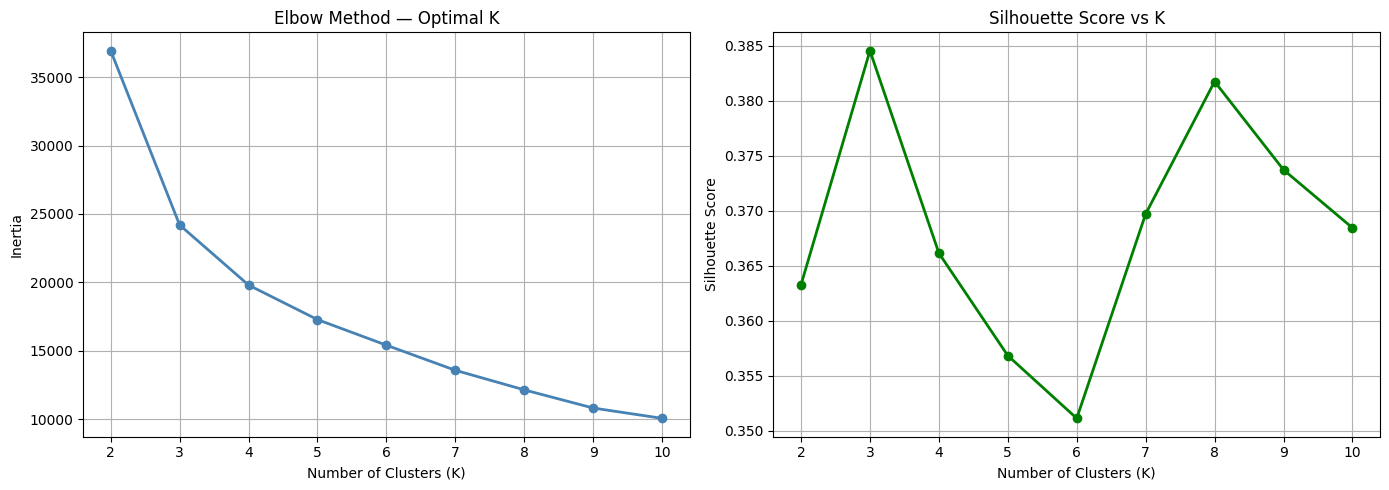


✅ Best K by Silhouette: 3


In [3]:
inertia    = []
sil_scores = []
k_range    = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)
    sil_scores.append(silhouette_score(X_scaled, kmeans.labels_))

# Plot Elbow Curve
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow
axes[0].plot(k_range, inertia, marker='o',
             color='steelblue', lw=2)
axes[0].set_title('Elbow Method — Optimal K')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia')
axes[0].grid(True)

# Silhouette
axes[1].plot(k_range, sil_scores, marker='o',
             color='green', lw=2)
axes[1].set_title('Silhouette Score vs K')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].grid(True)

plt.tight_layout()
plt.show()

print(f"\n✅ Best K by Silhouette: {k_range[np.argmax(sil_scores)]}")

In [4]:
# Train with 3 clusters (Low, Medium, High Risk)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

print("✅ K-Means Clustering Done!")
print("\nCluster Distribution:")
print(df['Cluster'].value_counts())

✅ K-Means Clustering Done!

Cluster Distribution:
Cluster
1    3005
2    2162
0    1876
Name: count, dtype: int64


In [5]:
# Analyze churn rate per cluster to assign risk labels
cluster_churn = df.groupby('Cluster')['Churn'].mean().sort_values(ascending=False)
print("\nChurn Rate per Cluster:")
print(cluster_churn)

# Map based on churn rate order
risk_map = {}
risk_labels = ['High Risk', 'Medium Risk', 'Low Risk']

for i, cluster_id in enumerate(cluster_churn.index):
    risk_map[cluster_id] = risk_labels[i]

df['RiskSegment'] = df['Cluster'].map(risk_map)

print("\nRisk Segment Distribution:")
print(df['RiskSegment'].value_counts())


Churn Rate per Cluster:
Cluster
2    0.513876
1    0.168719
0    0.133795
Name: Churn, dtype: float64

Risk Segment Distribution:
RiskSegment
Medium Risk    3005
High Risk      2162
Low Risk       1876
Name: count, dtype: int64


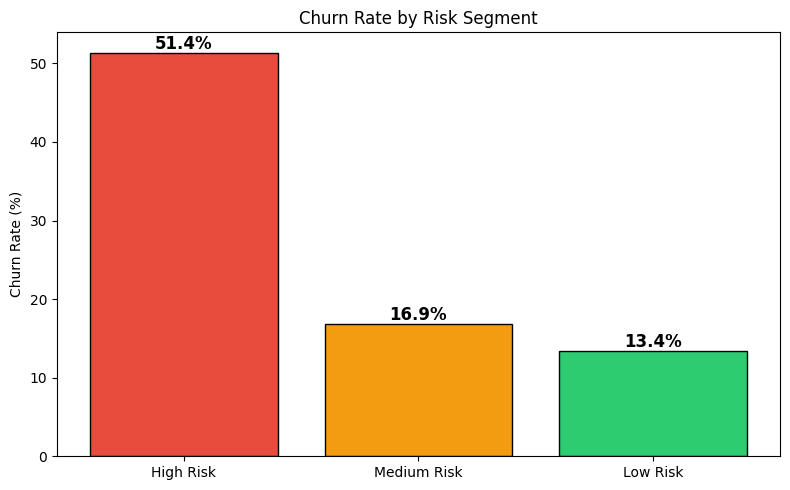

In [6]:
# Color map
colors = {
    'High Risk'   : '#e74c3c',
    'Medium Risk' : '#f39c12',
    'Low Risk'    : '#2ecc71'
}

# Churn rate by segment
plt.figure(figsize=(8, 5))
segment_churn = df.groupby('RiskSegment')['Churn'].mean() * 100
segment_churn = segment_churn.reindex(['High Risk', 'Medium Risk', 'Low Risk'])
bars = plt.bar(segment_churn.index,
               segment_churn.values,
               color=[colors[s] for s in segment_churn.index],
               edgecolor='black')

for bar, val in zip(bars, segment_churn.values):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.5,
             f'{val:.1f}%', ha='center',
             fontsize=12, fontweight='bold')

plt.title('Churn Rate by Risk Segment')
plt.ylabel('Churn Rate (%)')
plt.tight_layout()
plt.show()

In [7]:
# Profile each segment
profile = df.groupby('RiskSegment')[cluster_features + ['Churn']].mean().round(2)
profile = profile.reindex(['High Risk', 'Medium Risk', 'Low Risk'])

print("\n📊 Risk Segment Profiles:")
print("=" * 60)
print(profile.T)
print("=" * 60)


📊 Risk Segment Profiles:
RiskSegment          High Risk  Medium Risk  Low Risk
tenure                   16.53        26.48     60.06
MonthlyCharges           83.19        34.20     92.48
TotalCharges           1394.68       881.28   5547.97
CLV                    1396.60       875.98   5545.48
AvgMonthlySpend          83.11        34.07     92.53
ServiceCount              3.40         1.80      5.83
ContractRiskScore         2.90         2.26      1.72
ElectronicCheckFlag       0.60         0.20      0.26
HighSpendFlag             0.99         0.00      0.95
Churn                     0.51         0.17      0.13


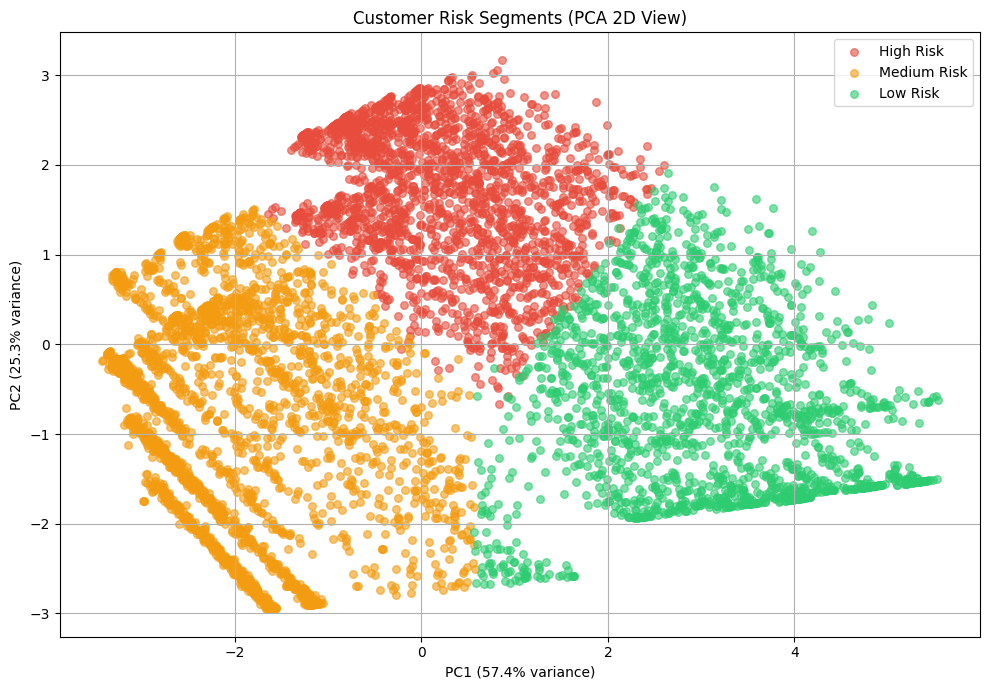

In [8]:
# Reduce to 2D using PCA
pca    = PCA(n_components=2, random_state=42)
X_pca  = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
pca_df['RiskSegment'] = df['RiskSegment'].values

# Plot
plt.figure(figsize=(10, 7))

for segment, color in colors.items():
    mask = pca_df['RiskSegment'] == segment
    plt.scatter(pca_df[mask]['PC1'],
                pca_df[mask]['PC2'],
                c=color, label=segment,
                alpha=0.6, s=30)

plt.title('Customer Risk Segments (PCA 2D View)')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

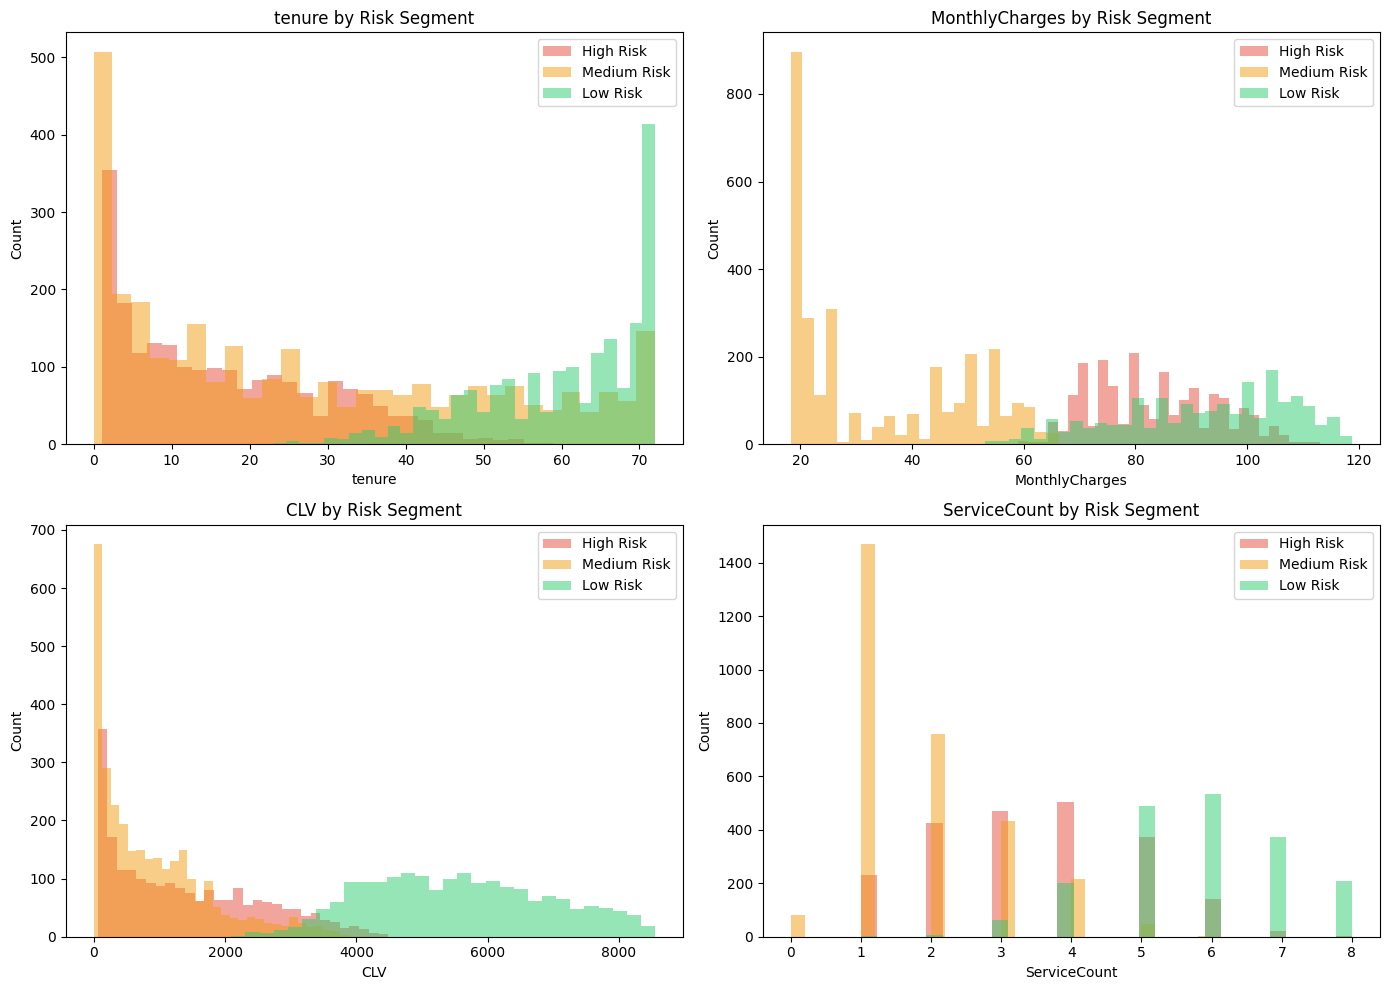

In [9]:
plot_features = ['tenure', 'MonthlyCharges', 'CLV', 'ServiceCount']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, feature in enumerate(plot_features):
    for segment, color in colors.items():
        mask = df['RiskSegment'] == segment
        axes[i].hist(df[mask][feature],
                     bins=30, alpha=0.5,
                     color=color, label=segment)
    axes[i].set_title(f'{feature} by Risk Segment')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Count')
    axes[i].legend()

plt.tight_layout()
plt.show()

In [10]:
print("\n")
print("=" * 60)
print("       RETENTION STRATEGY BY RISK SEGMENT")
print("=" * 60)

strategies = {
    'High Risk': [
        '🔴 Immediate personal outreach',
        '🔴 Offer loyalty discounts or upgrades',
        '🔴 Assign dedicated account manager',
        '🔴 Priority support & complaint resolution'
    ],
    'Medium Risk': [
        '🟡 Send re-engagement email campaigns',
        '🟡 Offer contract upgrade incentives',
        '🟡 Provide product usage tips & tutorials',
        '🟡 Monitor activity & trigger alerts'
    ],
    'Low Risk': [
        '🟢 Regular satisfaction surveys',
        '🟢 Reward loyalty with referral bonuses',
        '🟢 Upsell premium features',
        '🟢 Maintain consistent communication'
    ]
}

for segment, actions in strategies.items():
    print(f"\n  {segment}:")
    for action in actions:
        print(f"    {action}")

print("=" * 60)



       RETENTION STRATEGY BY RISK SEGMENT

  High Risk:
    🔴 Immediate personal outreach
    🔴 Offer loyalty discounts or upgrades
    🔴 Assign dedicated account manager
    🔴 Priority support & complaint resolution

  Medium Risk:
    🟡 Send re-engagement email campaigns
    🟡 Offer contract upgrade incentives
    🟡 Provide product usage tips & tutorials
    🟡 Monitor activity & trigger alerts

  Low Risk:
    🟢 Regular satisfaction surveys
    🟢 Reward loyalty with referral bonuses
    🟢 Upsell premium features
    🟢 Maintain consistent communication


In [11]:
# Save final dataset with risk segments
df.to_csv('segmented_churn_data.csv', index=False)

# Save clustering model
joblib.dump(kmeans, 'kmeans_model.pkl')
joblib.dump(pca, 'pca_model.pkl')

print("✅ Segmented dataset saved : segmented_churn_data.csv")
print("✅ KMeans model saved      : kmeans_model.pkl")
print("✅ PCA model saved         : pca_model.pkl")

# Final summary
print("\n📊 Final Segment Summary:")
summary = df.groupby('RiskSegment').agg(
    Total_Customers=('Churn', 'count'),
    Churn_Rate=('Churn', lambda x: f"{x.mean()*100:.1f}%"),
    Avg_CLV=('CLV', lambda x: f"${x.mean():.0f}"),
    Avg_Tenure=('tenure', lambda x: f"{x.mean():.0f} months")
).reindex(['High Risk', 'Medium Risk', 'Low Risk'])

print(summary)

✅ Segmented dataset saved : segmented_churn_data.csv
✅ KMeans model saved      : kmeans_model.pkl
✅ PCA model saved         : pca_model.pkl

📊 Final Segment Summary:
             Total_Customers Churn_Rate Avg_CLV Avg_Tenure
RiskSegment                                               
High Risk               2162      51.4%   $1397  17 months
Medium Risk             3005      16.9%    $876  26 months
Low Risk                1876      13.4%   $5545  60 months
